In [30]:
import jax.numpy as jnp
import immrax as irx
from immutabledict import immutabledict
from faulty_nonholonomic_car import FaultyNonHolonomicCar
# Define initial state bounds (intervals) using icentpert



# Create system instance with steering parameter p
car_system = FaultyNonHolonomicCar()

# Define the time horizon for reachability analysis
time_horizon = 1.0  # seconds
num_steps = 10  # Number of time steps

def propagate_interval(system, x0_interval, u_interval, w_interval, p_interval, t_end, dt=0.01):
    """
    Propagate the interval of states through the system dynamics for interval inputs.
    
    Args:
        system: The system with dynamics defined.
        x0_interval: Initial interval of states (as an interval object).
        u_interval: Interval of control inputs (as an interval object).
        w_interval: Interval of disturbance inputs (as an interval object).
        p_interval: Interval of parameter p (as an interval object).
        t_end: End time for propagation (e.g., 1 second).
        dt: Time step for numerical integration.
    
    Returns:
        Interval of states after propagation.
    """
    # Initialize the state interval
    x_interval = x0_interval

    # Time steps
    num_steps = int(t_end / dt)

    # Propagate the interval through the dynamics
    for _ in range(num_steps):
        # Extract lower and upper bounds for x, u, w, and p
        x_lower = x_interval.lower
        x_upper = x_interval.upper
        u_lower = u_interval.lower
        u_upper = u_interval.upper
        w_lower = w_interval.lower
        w_upper = w_interval.upper
        p_lower = p_interval.lower
        p_upper = p_interval.upper

        # Evaluate dynamics for all combinations of bounds
        combinations = [
            (x_lower, u_lower, w_lower, p_lower),
            (x_lower, u_lower, w_lower, p_upper),
            (x_lower, u_lower, w_upper, p_lower),
            (x_lower, u_lower, w_upper, p_upper),
            (x_lower, u_upper, w_lower, p_lower),
            (x_lower, u_upper, w_lower, p_upper),
            (x_lower, u_upper, w_upper, p_lower),
            (x_lower, u_upper, w_upper, p_upper),
            (x_upper, u_lower, w_lower, p_lower),
            (x_upper, u_lower, w_lower, p_upper),
            (x_upper, u_lower, w_upper, p_lower),
            (x_upper, u_lower, w_upper, p_upper),
            (x_upper, u_upper, w_lower, p_lower),
            (x_upper, u_upper, w_lower, p_upper),
            (x_upper, u_upper, w_upper, p_lower),
            (x_upper, u_upper, w_upper, p_upper),
        ]

        # Compute derivatives for all combinations
        dx_all = [system.f(0, x, u, w, p) for x, u, w, p in combinations]

        # Compute the minimum and maximum derivatives
        dx_min = jnp.min(jnp.stack(dx_all), axis=0)
        dx_max = jnp.max(jnp.stack(dx_all), axis=0)

        # Update the interval bounds using interval arithmetic
        x_lower_new = x_lower + dx_min * dt
        x_upper_new = x_upper + dx_max * dt

        # Create a new interval for the updated state
        x_interval = irx.interval(x_lower_new, x_upper_new)

    return x_interval

car_system = FaultyNonHolonomicCar()

# Define the initial interval of states
x0 = jnp.zeros(4)
x0_perturbation = jnp.array([.1, .1, .1, .1])
x0_interval = irx.icentpert(x0, x0_perturbation)

# Define the fixed control input and disturbance
u_fixed = jnp.array([1, 1])  # Fixed control input
u_interval = irx.icentpert(u_fixed, jnp.zeros_like(u_fixed))
w_fixed = jnp.array([jnp.pi/4])  # Fixed disturbance. Assume steering angle is fixed at 45 deg.
w_interval = irx.icentpert(w_fixed, jnp.zeros_like(w_fixed))
p_interval = irx.icentpert(jnp.array([.25]), jnp.array([.25]))
# Propagate the interval for 1 second
t_end = 1.0  # 1 second
x_interval_actuator_fault = propagate_interval(car_system, x0_interval=x0_interval, u_interval=u_interval, w_interval=w_interval, p_interval=p_interval, t_end=t_end)

# Print the resulting interval of states
print("Initial interval of states:", x0_interval)
print("Final interval of states after 1 second:", x_interval_actuator_fault)

Initial interval of states: [[(-0.1, 0.1)]
 [(-0.1, 0.1)]
 [(-0.1, 0.1)]
 [(-0.1, 0.1)]]
Final interval of states after 1 second: [[(0.38977659, 0.86622971)]
 [(0.22779396, 0.85201514)]
 [(0.6853984 , 1.38539803)]
 [(1.68539762, 1.88539755)]]


Generate Interval WITHOUT Actuator Fault

In [31]:
normal_car_system = FaultyNonHolonomicCar()

# Define the initial interval of states
x0 = jnp.zeros(4)
x0_perturbation = jnp.array([.1, .1, .1, .1])
x0_interval = irx.icentpert(x0, x0_perturbation)

# Define the fixed control input and disturbance
u_fixed = jnp.array([0.2, 0.2])  # Fixed control input
w_fixed = jnp.array([jnp.pi/4])  # Fixed disturbance. Assume steering angle is fixed at 45 deg.

# Propagate the interval for 1 second
t_end = 1.0  # 1 second
p_no_disturbance = irx.icentpert(jnp.array([1.0]), jnp.array([.0]))

x_interval_no_fault = propagate_interval(normal_car_system, x0_interval, u_interval, w_interval, p_no_disturbance, t_end)

# Print the resulting interval of states
print("Initial interval of states:", x0_interval)
print("Final interval of states after 1 second:", x_interval_no_fault)

Initial interval of states: [[(-0.1, 0.1)]
 [(-0.1, 0.1)]
 [(-0.1, 0.1)]
 [(-0.1, 0.1)]]
Final interval of states after 1 second: [[(0.10788131, 0.47474176)]
 [(0.55625081, 0.95028001)]
 [(1.68539762, 1.88539755)]
 [(1.68539762, 1.88539755)]]


Add an observation fault

In [32]:
offset = jnp.array([0.2, 0.2, 0., 0.2])
x_interval_observation_fault = x_interval_no_fault + offset

Plot observation of system

In [44]:
import matplotlib.pyplot as plt
def plot_observation_boxes(x_interval_actuator_fault, x_interval_no_fault, x_interval_observation_fault):
    # Extract the x and y positions from the final interval
    x_pos_interval_actuator_fault = x_interval_actuator_fault[0]  # x position interval
    y_pos_interval_actuator_fault = x_interval_actuator_fault[1]  # y position interval
    x_pos_interval_no_fault = x_interval_no_fault[0]
    y_pos_interval_no_fault = x_interval_no_fault[1]
    x_pos_interval_observation_fault = x_interval_observation_fault[0]
    y_pos_interval_observation_fault = x_interval_observation_fault[1]

    # Plot the interval of x and y positions
    plt.figure(figsize=(8, 6))
    plt.fill_between(
        [x_pos_interval_actuator_fault.lower, x_pos_interval_actuator_fault.upper],
        [y_pos_interval_actuator_fault.lower, y_pos_interval_actuator_fault.lower],
        [y_pos_interval_actuator_fault.upper, y_pos_interval_actuator_fault.upper],
        alpha=0.5,
        color="blue",
        label="Observation Set (x, y) - Actuator Fault"
    )
    plt.fill_between(
        [x_pos_interval_no_fault.lower, x_pos_interval_no_fault.upper],
        [y_pos_interval_no_fault.lower, y_pos_interval_no_fault.lower],
        [y_pos_interval_no_fault.upper, y_pos_interval_no_fault.upper],
        alpha=0.5,
        color="green",
        label="Observation Set (x, y) - No Fault"
    )
    plt.fill_between(
        [x_pos_interval_observation_fault.lower, x_pos_interval_observation_fault.upper],
        [y_pos_interval_observation_fault.lower, y_pos_interval_observation_fault.lower],
        [y_pos_interval_observation_fault.upper, y_pos_interval_observation_fault.upper],
        alpha=0.5,
        color="yellow",
        label="Observation Set (x, y) - Observer Fault"
    )
    plt.fill_between(
        [x0_interval.lower[0], x0_interval.upper[0]],
        [x0_interval.lower[1], x0_interval.lower[1]],
        [x0_interval.upper[1], x0_interval.upper[1]],
        color="red",
        label="Starting Observation"
    )
    plt.xlabel("x position")
    plt.ylabel("y position")
    plt.title("Observation of x and y Positions after 1 Second")
    plt.legend()
    plt.grid()
    plt.show()

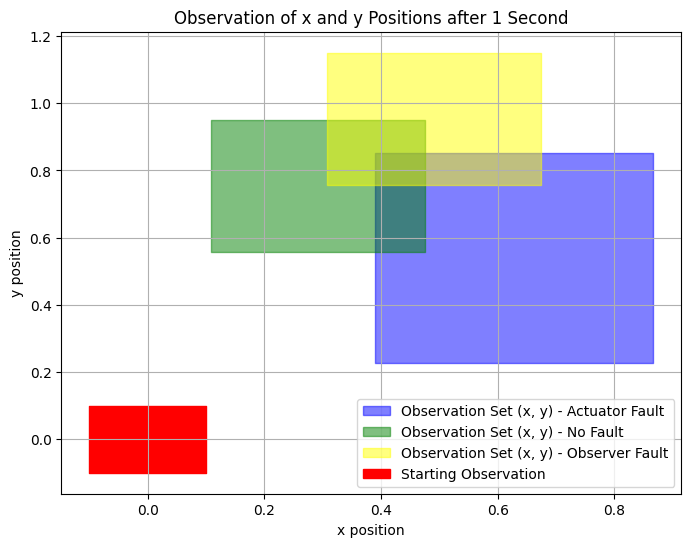

In [33]:
import matplotlib.pyplot as plt
# Extract the x and y positions from the final interval
x_pos_interval_actuator_fault = x_interval_actuator_fault[0]  # x position interval
y_pos_interval_actuator_fault = x_interval_actuator_fault[1]  # y position interval
x_pos_interval_no_fault = x_interval_no_fault[0]
y_pos_interval_no_fault = x_interval_no_fault[1]
x_pos_interval_observation_fault = x_interval_observation_fault[0]
y_pos_interval_observation_fault = x_interval_observation_fault[1]

# Plot the interval of x and y positions
plt.figure(figsize=(8, 6))
plt.fill_between(
    [x_pos_interval_actuator_fault.lower, x_pos_interval_actuator_fault.upper],
    [y_pos_interval_actuator_fault.lower, y_pos_interval_actuator_fault.lower],
    [y_pos_interval_actuator_fault.upper, y_pos_interval_actuator_fault.upper],
    alpha=0.5,
    color="blue",
    label="Observation Set (x, y) - Actuator Fault"
)
plt.fill_between(
    [x_pos_interval_no_fault.lower, x_pos_interval_no_fault.upper],
    [y_pos_interval_no_fault.lower, y_pos_interval_no_fault.lower],
    [y_pos_interval_no_fault.upper, y_pos_interval_no_fault.upper],
    alpha=0.5,
    color="green",
    label="Observation Set (x, y) - No Fault"
)
plt.fill_between(
    [x_pos_interval_observation_fault.lower, x_pos_interval_observation_fault.upper],
    [y_pos_interval_observation_fault.lower, y_pos_interval_observation_fault.lower],
    [y_pos_interval_observation_fault.upper, y_pos_interval_observation_fault.upper],
    alpha=0.5,
    color="yellow",
    label="Observation Set (x, y) - Observer Fault"
)
plt.fill_between(
    [x0_interval.lower[0], x0_interval.upper[0]],
    [x0_interval.lower[1], x0_interval.lower[1]],
    [x0_interval.upper[1], x0_interval.upper[1]],
    color="red",
    label="Starting Observation"
)
plt.xlabel("x position")
plt.ylabel("y position")
plt.title("Observation of x and y Positions after 1 Second")
plt.legend()
plt.grid()
plt.show()

In [34]:
def overlap_size(interval1, interval2):
    # Compute the intersection lower and upper bounds
    intersection_lower = jnp.maximum(interval1.lower, interval2.lower)
    intersection_upper = jnp.minimum(interval1.upper, interval2.upper)
    print(intersection_lower)
    print(intersection_upper)
    # Calculate the size of the intersection
    intersection_size = jnp.prod(jnp.maximum(intersection_upper - intersection_lower, 0))
    
    return intersection_size

In [35]:
def actuator_observer_fault_overlap(u_fixed):
    u_interval_in_function = irx.icentpert(u_fixed, jnp.zeros_like(u_fixed))
    x_interval_no_fault = propagate_interval(normal_car_system, x0_interval, u_interval_in_function, w_interval, p_no_disturbance, t_end)
    x_interval_actuator_fault = propagate_interval(car_system, x0_interval=x0_interval, u_interval=u_interval_in_function, w_interval=w_interval, p_interval=p_interval, t_end=t_end)
    x_interval_observation_fault = x_interval_no_fault + offset
    intersection_size = overlap_size(x_interval_observation_fault[0:2], x_interval_actuator_fault[0:2])
    return intersection_size

In [36]:
from jax import grad, jacfwd
# overlap_size(x_interval_actuator_fault[0:2], x_interval_observation_fault[0:2])
overlap_size_grad = grad(actuator_observer_fault_overlap)
overlap_size_jacobian = jacfwd(actuator_observer_fault_overlap)
print("Overlap size Gradient", overlap_size_grad(jnp.array([.1, .1])))
print("Overlap size Forward Jacobian", overlap_size_jacobian(jnp.array([.1, .1])))

Traced<ConcreteArray([0.38741937 0.26904762], dtype=float32)>with<JVPTrace(level=2/0)> with
  primal = Array([0.38741937, 0.26904762], dtype=float32)
  tangent = Traced<ShapedArray(float32[2])>with<JaxprTrace(level=1/0)> with
    pval = (ShapedArray(float32[2]), None)
    recipe = JaxprEqnRecipe(eqn_id=<object object at 0x7bb362a31070>, in_tracers=(Traced<ShapedArray(float32[2]):JaxprTrace(level=1/0)>, Traced<ShapedArray(float32[2]):JaxprTrace(level=1/0)>, Traced<ConcreteArray([1. 1.], dtype=float32):JaxprTrace(level=1/0)>, Traced<ConcreteArray([0. 0.], dtype=float32):JaxprTrace(level=1/0)>), out_tracer_refs=[<weakref at 0x7bb362a6d2b0; to 'JaxprTracer' at 0x7bb362a6cef0>], out_avals=[ShapedArray(float32[2])], primitive=pjit, params={'jaxpr': { lambda ; a:f32[2] b:f32[2] c:f32[2] d:f32[2]. let
    e:f32[2] = mul a c
    f:f32[2] = mul b d
    g:f32[2] = add_any e f
  in (g,) }, 'in_shardings': (UnspecifiedValue, UnspecifiedValue, UnspecifiedValue, UnspecifiedValue), 'out_shardings': (U

In [40]:
# Gradient descent parameters
learning_rate = 10  # Step size for gradient descent
max_iterations = 1000  # Maximum number of iterations
tolerance = 1e-6  # Convergence tolerance

# Initial control input (replace with your initial guess)
u = jnp.array([0.0, 0.0])

# Gradient descent loop
for i in range(max_iterations):
    # Compute the overlap size and its gradient
    intersection_size = actuator_observer_fault_overlap(u)
    gradient = overlap_size_jacobian(u)
    
    # Check for convergence
    if jnp.abs(intersection_size) < tolerance:
        print(f"Converged at iteration {i} with overlap size {intersection_size}")
        break
    
    # Update the control input using gradient descent
    u = u - learning_rate * gradient
    
    # Print progress
 
    print(f"Iteration {i}: overlap size = {intersection_size}, u = {u}")

[0.35534322 0.22865346]
[0.49677277 0.36833143]
Traced<ConcreteArray([0.35534322 0.22865346], dtype=float32)>with<JVPTrace(level=2/0)> with
  primal = Array([0.35534322, 0.22865346], dtype=float32)
  tangent = Traced<ShapedArray(float32[2])>with<BatchTrace(level=1/0)> with
    val = Array([[-0.09930387,  0.18095408],
       [ 0.44405216,  0.19914055]], dtype=float32)
    batch_dim = 0
Traced<ConcreteArray([0.49677277 0.36833143], dtype=float32)>with<JVPTrace(level=2/0)> with
  primal = Array([0.49677277, 0.36833143], dtype=float32)
  tangent = Traced<ShapedArray(float32[2])>with<BatchTrace(level=1/0)> with
    val = Array([[-0.04748814,  0.05918648],
       [ 0.39563748,  0.28339058]], dtype=float32)
    batch_dim = 0
Iteration 0: overlap size = 0.019754592329263687, u = [ 0.09984019 -0.05152979]
[0.32271224 0.23459524]
[0.46723735 0.364725  ]
Traced<ConcreteArray([0.32271224 0.23459524], dtype=float32)>with<JVPTrace(level=2/0)> with
  primal = Array([0.32271224, 0.23459524], dtype=flo

In [42]:
print("Optimal u: ", u)

Optimal u:  [-0.37646583 -1.2748882 ]


In [46]:
optimal_u = u
optimal_u_interval = irx.icentpert(optimal_u, jnp.zeros_like(optimal_u))
x_interval_no_fault = propagate_interval(normal_car_system, x0_interval, optimal_u_interval, w_interval, p_no_disturbance, t_end)
x_interval_actuator_fault = propagate_interval(car_system, x0_interval=x0_interval, u_interval=optimal_u_interval, w_interval=w_interval, p_interval=p_interval, t_end=t_end)
x_interval_observation_fault = x_interval_no_fault + offset

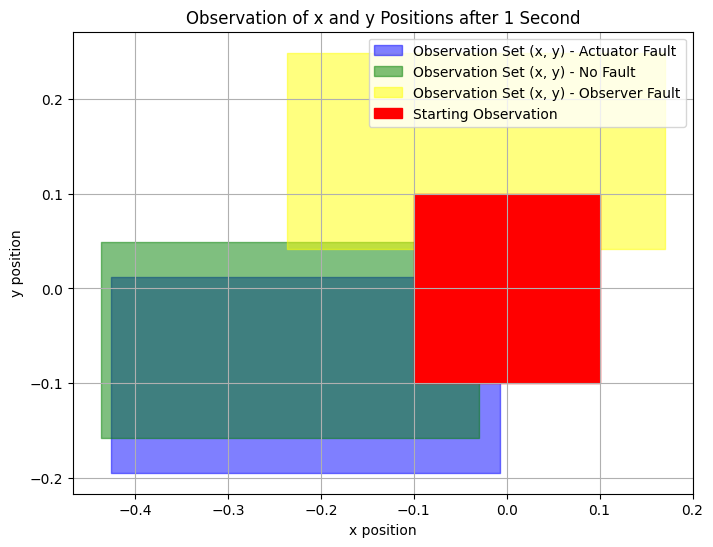

In [47]:
plot_observation_boxes(x_interval_no_fault=x_interval_no_fault, x_interval_actuator_fault=x_interval_actuator_fault, x_interval_observation_fault=x_interval_observation_fault)